# Chapter 13: Reproducing a Published Result

<a href="https://colab.research.google.com/github/choilab-jefferson/medimage/blob/main/Chapter13_Reproducibility.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Every chapter so far ended by checking a number. This one checks a *paper*.

In 2014 Aerts and colleagues published one of the most cited results in radiomics: features extracted
from CT scans of lung tumors carry prognostic information about how long patients survive. The
analysis was done on a cohort known as **Lung1**, and both the images and the survival data are
public.

So the natural question is whether the result comes back out. Not "is the paper right" — that is a
different and much larger question — but the narrower and more useful one: **if I run a pipeline of
the same shape on the same public data, do I land somewhere near the published number?**

That question is worth more than it sounds. A pipeline that cannot reproduce a known result is not
ready to produce a new one.

By the end of this chapter you will have:

1. Run a complete radiomics study end to end, from download to survival statistics.
2. Compared your result against both a full-cohort reproduction and the published number.
3. Seen exactly how badly a small cohort behaves, and learned to recognize the symptoms.

### Before you start

| | |
|---|---|
| **Builds on** | Chapter 9 explains what the 1130 features are; Chapter 12 shares this cohort. Neither is required first |
| **Downloads** | The **Lung1 cohort, 60 patients at roughly 25 MB each — around 1.5 GB** |
| **Longest wait** | The full `qr` chain in section 1: download, contour conversion, resampling and extraction. Budget a long coffee on a cold cache |
| **Beyond the setup cell** | `pyradiomics` (from git), `qradiomics`, `rt-utils`, `opencv-python-headless` |
| **Hardware** | Any laptop. No GPU needed |

Everything is cached per patient, so a re-run costs nothing and raising `N_PATIENTS` only fetches
the new ones. On Colab the cache lives in the runtime and disappears with the session.

This chapter is mostly `qr` command-line calls rather than Python, which is deliberate — it is what
running a real study looks like. **Expect the reproduction to fail at 60 patients.** That is the
result, not a mistake in your run, and section 6 is where it is explained.

## Setup

This chapter is driven by the `qr` command-line tool from
[qradiomics](https://github.com/choilab-jefferson/qradiomics), so most cells are shell commands
rather than Python.

Note the `opencv-python-headless` install. Converting radiotherapy contours needs `rt-utils`, which
pulls in OpenCV, and the ordinary OpenCV build requires a graphics library that servers and
containers do not have. Without the headless build every contour conversion fails with
`libGL.so.1: cannot open shared object file` — an error that looks nothing like its cause.

In [1]:
# --- Setup: Google Colab (primary) and local checkout (testing) ---------------
REPO_URL = "https://github.com/choilab-jefferson/medimage.git"
REPO_DIR = "medimage"

import os
import pathlib
import subprocess
import sys

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB:
    # On Colab the repository is not present yet, so clone it and install the
    # few packages that are not part of the default runtime.
    if not pathlib.Path(REPO_DIR).is_dir():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir(REPO_DIR)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "pydicom", "remotezip"],
        check=True,
    )
else:
    # Locally the notebook already lives inside the repository; walk up until
    # we find the module that the notebooks import.
    root = pathlib.Path.cwd().resolve()
    while not (root / "medimage_data.py").is_file() and root != root.parent:
        root = root.parent
    os.chdir(root)

print("Running on Colab:", IN_COLAB)
print("Working directory:", pathlib.Path.cwd().name)

Running on Colab: False
Working directory: medimage


In [2]:
import subprocess
import sys

# pyradiomics is the default extraction engine, and an optional extra of
# qradiomics: PyPI ships no wheel for Python 3.10+, so it comes from git.
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "pyradiomics @ git+https://github.com/AIM-Harvard/pyradiomics.git",
                "qradiomics", "rt-utils", "opencv-python-headless"], check=True)

print(subprocess.run(["qr", "info"], capture_output=True, text=True).stdout.strip())

qradiomics v0.9.5
Aliases: qradiomics, qr, qrdx
Verbose: False


In [3]:
import json
import pathlib

import matplotlib.pyplot as plt
import pandas as pd

import medimage_data as md

# How many patients to use. The full cohort is 422. Survival signal is weak at
# small n, so raise this if you have the time and disk space; the download is
# roughly 25 MB per patient.
N_PATIENTS = 60

print(f"running on {N_PATIENTS} patients")

running on 60 patients


## 1. The cohort

Preparing Lung1 means downloading the scans, converting the radiotherapy contours to masks,
cropping and resampling, extracting features and joining the clinical table. That is real work, but
it is *plumbing*, not reproduction — so it lives in a loader, the same way every other dataset in
this course does.

One detail inside it is worth knowing about, because getting it wrong is silent. A structure set
holds many contours — lungs, spinal cord, esophagus, treatment volumes — and a converter told only
"convert the structure set" takes the first one. In Lung1 that is frequently a lung rather than the
tumor. The loader passes `--roi GTV-1` explicitly. Without it the pipeline still runs, still
produces features, and measures the wrong organ.

In [4]:
paths = md.fetch_lung1_cohort(N_PATIENTS)

ready = pd.read_csv(paths["analysis_ready"])
print()
print(f"{len(ready)} patients, {ready.shape[1] - 3} features per patient")
print(f"{ready.OS_event.sum()} deaths observed, median follow-up "
      f"{ready.OS_months.median():.1f} months")

  LUNG1-035: no GTV-1 contour in the structure set, skipping


Lung1 cohort ready: 59 patients, 1130 features in work/lung1
Source: Aerts HJWL, Wee L, Rios Velazquez E, et al. (2019). Data From NSCLC-Radiomics. The Cancer Imaging Archive. https://doi.org/10.7937/K9/TCIA.2015.PF0M9REI  (CC BY-NC 3.0)

59 patients, 1130 features per patient
54 deaths observed, median follow-up 11.2 months


The feature count is worth pausing on. The `nsclc-survival` pattern reproduces the feature space the
paper used — the original image plus wavelet, Laplacian-of-Gaussian, square, square-root and
logarithm transforms across seven feature classes — which is about **1130 numbers per patient**.

We are about to fit a survival model with roughly twenty times more features than patients.

## 2. Which features look prognostic?

`qr analyze survival` fits a separate Cox proportional-hazards model for each feature and reports
its hazard ratio and p-value. A hazard ratio above 1 means higher values go with shorter survival.

In [5]:
cox_csv = paths["work"] / "cox.csv"
subprocess.run(["qr", "analyze", "survival", "-i", str(paths["analysis_ready"]),
                "--outcome", "OS_months", "--event", "OS_event",
                "-o", str(cox_csv), "--top-n", "10"], check=True)

cox = pd.read_csv(cox_csv)
print(f"\n{len(cox)} features fitted, {(cox.p < 0.05).sum()} significant at p < 0.05")
print(f"expected by chance alone at p < 0.05: about {0.05 * len(cox):.0f}")

Running univariate Cox PH: 1130 features, 59 patients...



──────────────────────────────────────────────────────────────
Cox PH Univariate  |  1129 features  |  160 significant (p<0.05)
──────────────────────────────────────────────────────────────
  Feature                                          HR         p
──────────────────────────────────────────────────────────────
* wavelet-LLL_glszm_GrayLevelNonUniformity      1.002    0.0008
* wavelet-HHH_glszm_GrayLevelNonUniformity      1.028    0.0013
* wavelet-HHL_glszm_SizeZoneNonUniformity       1.001    0.0015
* wavelet-HHH_glszm_SizeZoneNonUniformity       1.017    0.0020
* wavelet-HLH_glszm_SmallAreaEmphasis          104386.712    0.0020
* wavelet-HHL_firstorder_TotalEnergy            1.000    0.0022
* wavelet-HHL_firstorder_Energy                 1.000    0.0022
* wavelet-HHH_firstorder_TotalEnergy            1.000    0.0024
* wavelet-HHH_firstorder_Energy                 1.000    0.0024
* square_glrlm_GrayLevelNonUniformity           1.000    0.0032
─────────────────────────────────────


1129 features fitted, 160 significant at p < 0.05
expected by chance alone at p < 0.05: about 56


Compare those two numbers before reading anything into the ranking.

Testing 1130 features at p < 0.05 produces about 56 "significant" results even if no feature carries
any signal at all. This is the multiple-comparisons problem, and in radiomics it is not a
technicality — it is the central difficulty. A single p-value from a list this long is close to
meaningless on its own.

In [6]:
top = cox.nsmallest(8, "p")[["feature", "hr", "p"]]
pd.set_option("display.width", 140)
print(top.to_string(index=False))

extreme = (cox.hr > 1e6) | (cox.hr < 1e-6)
print(f"\nfeatures with hazard ratios beyond 1e6 or below 1e-6: {extreme.sum()}")

                                 feature            hr        p
wavelet-LLL_glszm_GrayLevelNonUniformity      1.001886 0.000802
wavelet-HHH_glszm_GrayLevelNonUniformity      1.027920 0.001276
 wavelet-HHL_glszm_SizeZoneNonUniformity      1.000505 0.001511
 wavelet-HHH_glszm_SizeZoneNonUniformity      1.016869 0.002007
     wavelet-HLH_glszm_SmallAreaEmphasis 104386.712410 0.002026
      wavelet-HHL_firstorder_TotalEnergy      1.000000 0.002223
           wavelet-HHL_firstorder_Energy      1.000000 0.002223
      wavelet-HHH_firstorder_TotalEnergy      1.000000 0.002392

features with hazard ratios beyond 1e6 or below 1e-6: 132


Look at the size of those hazard ratios. A plausible clinical hazard ratio is something like 1.5 or
2. Values of $10^{20}$ or $10^{-100}$ are not findings — they are the arithmetic telling you that
the model separated the data perfectly because there were too few patients to constrain it.

**Absurd numbers are a symptom, and a useful one.** They are easier to notice than a quietly
overfitted model that produces believable-looking values.

## 3. Cross-validated prediction

Univariate p-values say which features *look* associated with survival in the data you have. They do
not say whether a model built from them predicts anything about patients it has never seen.

For that you need cross-validation: fit on part of the cohort, predict the rest, repeat. The score
is the **concordance index (c-index)** — the probability that, given two patients, the model
correctly identifies which one died first.

- **0.5** — no better than a coin toss.
- **0.65** — the value Aerts reported on the full Lung1 cohort.
- **1.0** — perfect.

In [7]:
metrics_json = paths["work"] / "metrics.json"
subprocess.run(["qr", "ml", "train", "-i", str(paths["analysis_ready"]),
                "--task", "survival", "--outcome", "OS_event", "--time-col", "OS_months",
                "--folds", "5", "--top-features", "30",
                "--model", str(paths["work"] / "model.pkl"), "--metrics", str(metrics_json)], check=True)

metrics = json.loads(metrics_json.read_text())
c_index = metrics["cv_c_index_mean"]

print()
print(f"patients            : {metrics['n']}")
print(f"cross-validated c-index: {c_index:.3f} +/- {metrics['cv_c_index_std']:.3f}")
print(f"95% confidence interval: [{metrics['cv_c_index_ci_lo']:.3f}, "
      f"{metrics['cv_c_index_ci_hi']:.3f}]")

qr ml train: task=survival outcome=OS_event input=work/lung1/analysis_ready.csv
  feature reduction: corr<0.95, top-30
  loaded 59 rows × 1133 cols


  [survival] 59 rows, 1130 candidate features
  [survival] events=54/59


  [survival] cross-validating (5-fold, feature selection per fold)


    fold 1/5: c-index=0.415 (train=47, test=12, k=30)


    fold 2/5: c-index=0.561 (train=47, test=12, k=30)


...

    fold 5/5: c-index=0.509 (train=48, test=11, k=30)


  [survival] pooled c-index 95% CI = [0.377, 0.558]  IBS=0.246
  [survival] fitting final model on all 59 samples


  [survival] final feature set: 30 features


Model -> work/lung1/model.pkl
Metrics -> work/lung1/metrics.json
  CV c-index: 0.482 ± 0.051



patients            : 59
cross-validated c-index: 0.482 +/- 0.051
95% confidence interval: [0.377, 0.558]


## 4. The comparison

Three numbers for the same analysis at three different scales.

In [8]:
comparison = pd.DataFrame([
    {"run": "this notebook", "patients": metrics["n"],
     "c_index": round(c_index, 3), "source": "computed just now"},
    {"run": "full-cohort reproduction", "patients": 420,
     "c_index": 0.580, "source": "qradiomics reproducibility report"},
    {"run": "Aerts et al. 2014", "patients": 422,
     "c_index": 0.650, "source": "published"},
])

print(comparison.to_string(index=False))

                     run  patients  c_index                            source
           this notebook        59    0.482                 computed just now
full-cohort reproduction       420    0.580 qradiomics reproducibility report
       Aerts et al. 2014       422    0.650                         published


### Reading the table

**Our run finds nothing.** At sixty patients the cross-validated c-index comes out at roughly 0.48 —
marginally *below* chance — with a confidence interval that comfortably contains 0.5. Individual
folds scatter from about 0.42 to 0.56, which is the scatter you would get from shuffling the
outcomes.

It is worth being precise about what that means, because the temptation is to read it as a weak
positive result. It is not. A model that scores below 0.5 has not found a faint signal; it has found
none, and the small deviation is noise. With over a thousand features and fewer than sixty patients,
the model has enough freedom to fit the training folds perfectly and no reason for those fits to
carry over to the held-out patients.

**Do not tune your way out of this.** Faced with 0.48 it is easy to try a different feature count, a
different penalty, a different fold count, and stop when a run happens to produce 0.6. That number
would be a description of the search, not of the data. The conclusion from this run is that
sixty patients cannot answer the question.

**The full-cohort reproduction reaches 0.580 against a published 0.650.** That gap is a real and
common finding. Reproductions of radiomics results usually land below the original, and the reasons
are mundane rather than sinister: image preprocessing choices, which contour was used, feature
software versions, and how the model was selected. The published figure also came from a pipeline
tuned on that data, while a reproduction applies a fixed recipe.

**What survives is the direction, not the decimal.** Both reproductions land above 0.5, so the claim
that CT texture carries prognostic information holds. The claim that it carries *exactly* 0.65 worth
does not travel as well.

That distinction is the most useful thing in this chapter. "Does the effect reproduce?" and "does
the number reproduce?" are different questions, and confusing them is how radiomics acquired its
reputation for irreproducibility.

## 5. A second kind of reproduction

The Aerts result is the obvious target because it is the most cited, but it is also the hardest to
reproduce exactly — a signature fitted to one cohort, using software that has changed since.

A different question is whether a *method* reproduces: if a paper describes how to compute
something, does an independent implementation get the same answer? That is a cleaner test, and it is
where the qradiomics reproducibility work concentrates.

| Paper | Cohort | Method | Reproduced | Published |
|---|---|---|---|---|
| Aerts 2014 | Lung1, n=420 | Cox PH, 5-fold CV | c-index 0.580 | 0.65 |
| Aerts 2014, external | Lung1 to NSCLC-Cetuximab | signature transfer | c-index 0.562 | 0.69 |
| Choi 2014 CMPB | LIDC-IDRI, 1,018 scans | AHSN + random forest | AUC 0.727 | 0.85-0.93 |
| Choi 2018 Med Phys | LIDC-IDRI, 4,248 nodules | radiomics50 | AUC 0.872 | 0.83-0.95 |
| **Choi 2021 CMPB** | LIDC-IDRI, 4,248 nodules | **spic6** | **AUC 0.816** | **0.80-0.85** |
| Choi 2021 CMPB | LIDC-PM, 474 nodules | radiomics + spic | AUC 0.868 | 0.85 |
| Choi 2021 CMPB | LUNGx external | radiomics50 | AUC 0.756 | 0.76 |
| Choi 2022 MICCAI | LIDC-PM + LUNGx | interpretable | AUC 0.755-0.868 | 0.813 / 0.743 |

Notice the pattern. The Aerts reproduction lands 0.07 below the paper. Three of the four Choi
reproductions land **at or above** their published numbers, and the spiculation row matches almost
exactly.

The difference is not that one group was more careful than the other. It is that a *geometric*
measurement — counting how many spikes a nodule has — is defined by its algorithm, so an independent
implementation converges on the same value. A *fitted signature* depends on the cohort, the software
version and the modeling choices, none of which travel intact.

**Methods reproduce more reliably than models.** That is worth knowing before deciding what to build.

### Spiculation, and why it is interpretable

A lung nodule that is smooth and round is usually benign. One with spikes radiating outward —
**spiculated** — is far more likely to be malignant, because those spikes are the tumor pulling on
surrounding tissue as it invades. Radiologists have used this sign for decades.

The 1130 texture features above carry no such meaning. `wavelet-HHH_glcm_Imc2` may predict survival,
but nobody can say what it *is*. Spiculation features are the opposite: six numbers, each counting a
specific geometric property of the nodule surface.

| Feature | What it counts |
|---|---|
| `spic_Np` | spikes, sharp protrusions |
| `spic_Na` | lobulations, rounded bulges |
| `spic_Nl` | attached structures |
| `spic_Na_att` | attached lobulations |
| `spic_s1`, `spic_s2` | sharpness of the spikes |

`qr shape` computes these alongside AHSN, the area-histogram descriptor from the 2014 paper.

In [9]:
shape_csv = paths["work"] / "shape.csv"
if not shape_csv.exists():
    subprocess.run(["qr", "shape", "extract",
                    "-m", str(paths["cropped"] / "manifest.csv"),
                    "-o", str(shape_csv),
                    "--ahsn", "--spiculation", "-j", "4"], check=True)

shape = pd.read_csv(shape_csv)
spic = [c for c in shape.columns if c.startswith("spic_")]
ahsn = [c for c in shape.columns if c.startswith("ahsn_")]

print(f"{len(shape)} patients")
print(f"  {len(ahsn)} AHSN descriptors")
print(f"  {len(spic)} spiculation features: {spic}")
print()
print(shape[["patient_id"] + spic].head(8).to_string(index=False))

59 patients
  180 AHSN descriptors
  6 spiculation features: ['spic_Np', 'spic_Na', 'spic_Nl', 'spic_Na_att', 'spic_s1', 'spic_s2']

patient_id  spic_Np  spic_Na  spic_Nl  spic_Na_att   spic_s1  spic_s2
 LUNG1-003    219.0     74.0    144.0          0.0 -1.117236 0.305739
 LUNG1-006    503.0    161.0    339.0          0.0 -0.652395 0.229245
 LUNG1-005    424.0    172.0    251.0          0.0 -0.975609 0.348615
 LUNG1-010    153.0     43.0    110.0          0.0 -0.737318 0.238467
 LUNG1-008    255.0     68.0    187.0          0.0 -0.403394 0.070229
 LUNG1-004    548.0    201.0    345.0          0.0 -1.140259 0.327388
 LUNG1-011    428.0    163.0    260.0          0.0 -0.754236 0.186850
 LUNG1-007    120.0     33.0     87.0          0.0 -0.374007 0.067718


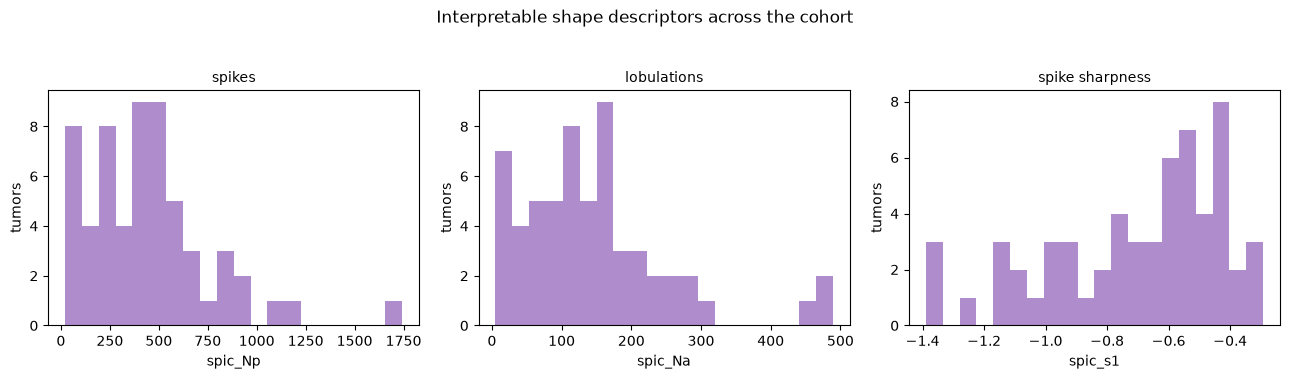

Six numbers per tumor, each with a stated geometric meaning - against
1130 texture features whose meaning is not stated anywhere.


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, feature in zip(axes, ["spic_Np", "spic_Na", "spic_s1"]):
    ax.hist(shape[feature].dropna(), bins=20, color="tab:purple", alpha=0.75)
    ax.set_xlabel(feature)
    ax.set_ylabel("tumors")
axes[0].set_title("spikes", fontsize=10)
axes[1].set_title("lobulations", fontsize=10)
axes[2].set_title("spike sharpness", fontsize=10)
fig.suptitle("Interpretable shape descriptors across the cohort", y=1.04)
plt.tight_layout()
plt.show()

print("Six numbers per tumor, each with a stated geometric meaning - against")
print(f"{ready.shape[1] - 3} texture features whose meaning is not stated anywhere.")

That contrast is the practical argument for interpretable features. When a clinician asks *why* a
model flagged a patient, "it has four spikes and high spike sharpness" is an answer.
"Its wavelet-HHH gray-level co-occurrence informational measure of correlation 2 was elevated" is not.

## 6. Raising the patient count

Change `N_PATIENTS` at the top and re-run. The cells are cached, so only the new patients are
downloaded and extracted. Watch what happens as it climbs:

| Patients | Measured here |
|---|---|
| 12 | c-index exactly 0.500, hazard ratios up to $10^{96}$ |
| 60 | c-index 0.48, CI [0.38, 0.56] — indistinguishable from chance |
| 150+ | not run here; expect the interval to start narrowing |
| 422 | 0.580 in the reproducibility report |

The first two rows were measured while writing this chapter. Nothing about the method changes
between them and the last row — only the amount of data. That alone is the difference between a
result and a coin toss.

## Limitations

- **Not the published pipeline.** Aerts et al. used a specific four-feature signature fitted their
  way. This is a pipeline of the same shape, not a line-by-line reimplementation, so exact agreement
  was never the goal.
- **No external validation.** The published claim was tested by transferring the signature to
  independent cohorts. Doing that here would need a second dataset.
- **The first N patients, not a random sample.** Convenient and reproducible, but a genuine study
  would sample properly.
- **One extraction setting.** Bin width, resampling and interpolation all move radiomics features,
  and this notebook fixes them without exploring the alternatives.

## Recap

The pipeline, end to end. Note what it is made of: a handful of `qr` commands, most of them run for
you inside `md.fetch_lung1_cohort`, rather than a codebase of your own.

| Step | Command |
|---|---|
| **Download** | `qr tcia download` |
| **Convert contours** | `qr convert`, turning RTSTRUCT outlines into masks |
| **Preprocess** | `qr preprocess`, cropping and resampling to a fixed voxel size |
| **Extract** | `qr extract`, giving 1130 features per patient |
| **Merge outcomes** | `qr results merge`, joining the clinical table onto the feature table |
| **Analyze** | `qr analyze survival`, giving a c-index and hazard ratios |

**What reproduced and what did not.** At 60 patients the c-index was 0.48, with a confidence
interval spanning chance. The full-cohort reproduction reaches 0.580, against 0.650 published. The
method did not change between those rows — only the amount of data. At 12 patients the symptoms are
unmistakable once you know them: a c-index of exactly 0.500 and hazard ratios around $10^{96}$ are
not weak findings but a model with nothing to fit.

**The second reproduction worked better.** Geometric shape features — spiculation and its relatives —
came back more consistently than the fitted survival model, and they carry a second advantage: when
a clinician asks why a patient was flagged, "it has four spikes and high spike sharpness" is an
answer, and "its wavelet-HHH GLCM informational measure of correlation 2 was elevated" is not.

**Where this leaves the course.** The recurring question in all thirteen chapters was *is this
number right*, and the answers accumulated into one method: know what the units mean (Ch 1–3), check
against a reference (Ch 3, 6), measure your own noise floor (Ch 7, 11), distrust a result that is
too good (Ch 12), and confirm the pipeline can recover something already known before asking it
something new (this chapter). A pipeline that cannot reproduce a known result is not ready to
produce a new one.

## Exercises

1. Set `N_PATIENTS` to 20 and then to 100 and record the c-index each time. Plot it against patient
   count. Where does it start to stabilize?

   *Hint:* plot the confidence interval, not just the point estimate — the interval narrowing is the
   real signal, and the point estimate will bounce around unhelpfully. Caching means each step only
   costs the new patients.

2. Re-run the extraction with `--bin-width 10` instead of the pattern default. How much do the
   feature values move? How much does the c-index move?

   *Hint:* Chapter 9 measured the first half — expect roughly two thirds of features to move more
   than 10%. The interesting part is the second half: a large movement in the inputs need not move
   the c-index, because on this cohort the interval is wide enough to hide it.

3. Convert a structure set *without* `--roi GTV-1` and compare the mask with the correct one using
   Chapter 3's Dice function. What organ did you actually get?

   *Hint:* the structure set holds several ROIs — lungs and cord among them — and without the flag
   you get whichever comes first, not an error. Extraction then runs happily and returns 1130
   perfectly valid numbers about the wrong structure.

4. Of the features ranked most significant, how many would you still expect to be significant after
   correcting for 1130 tests (try Bonferroni: divide 0.05 by the number of tests)?

   *Hint:* the threshold becomes 0.05 / 1130 ≈ 4.4 × 10⁻⁵. Compare it against the p-values in the
   table. Bonferroni is conservative and the features are highly correlated, so this is an upper
   bound on the correction — but if nothing survives it, that is worth knowing before writing the
   result up.

## References

- Aerts HJWL, Velazquez ER, Leijenaar RTH, et al. *Decoding tumor phenotype by noninvasive imaging
  using a quantitative radiomics approach.* Nature Communications. 2014;5:4006.
  [doi:10.1038/ncomms5006](https://doi.org/10.1038/ncomms5006)
- Aerts HJWL, Wee L, Rios Velazquez E, et al. (2019). *Data From NSCLC-Radiomics.*
  The Cancer Imaging Archive.
  [doi:10.7937/K9/TCIA.2015.PF0M9REI](https://doi.org/10.7937/K9/TCIA.2015.PF0M9REI)
- van Griethuysen JJM, Fedorov A, Parmar C, et al. *Computational radiomics system to decode the
  radiographic phenotype.* Cancer Research. 2017;77(21):e104–e107.
- Harrell FE, Califf RM, Pryor DB, et al. *Evaluating the yield of medical tests.* JAMA.
  1982;247(18):2543–2546. — the concordance index.